In [1]:
%pip install -q git+https://github.com/huggingface/transformers.git
%pip install -q datasets langchain-text-splitters sentence-transformers scikit-learn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import re
import os
import json
import random

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from tqdm.auto import tqdm
from datasets import load_dataset
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [27]:
DATASET_NAME = "openbmb/Ultra-FineWeb"
SUBSET = "default"  # или "default" для полного
SPLIT = "en"
MAX_DOCS = 1000  # для теста

print(f"Загрузка {DATASET_NAME} ({SUBSET})...")
dataset = load_dataset(DATASET_NAME, SUBSET, split=SPLIT, streaming=True)

texts = []
for i, item in enumerate(dataset):
    if i >= MAX_DOCS:
        break
    texts.append(item["content"])

print(f"Загружено {len(texts)} документов")
print(f"Пример документа (первые 200 символов):")
print(repr(texts[0][:200]))

Загрузка openbmb/Ultra-FineWeb (default)...


Resolving data files:   0%|          | 0/2048 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/256 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2048 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/256 [00:00<?, ?it/s]

Загружено 1000 документов
Пример документа (первые 200 символов):
'An ST-elevation myocardial infarction (STEMI) is a type of heart attack that mainly affects your heart’s lower chambers. They are named for how they change the appearance of your heart’s electrical ac'


In [100]:
import random

print(
    random.choice(texts)
)

Margin of Safety (MOS)
In break-even analysis, margin of safety is the extent by which actual or projected sales exceed the break-even sales. It may be calculated simply as the difference between actual or projected sales and the break-even sales. However, it is best to calculate margin of safety in the form of a ratio. Thus we have the following two formulas to calculate margin of safety:
|MOS = Budgeted Sales − Break-even Sales|
|MOS =||Budgeted Sales − Break-even Sales|
Margin of Safety can be expressed both in terms of sales units and currency units.
The margin of safety is a measure of risk. It represents the amount of drop in sales which a company can tolerate. Higher the margin of safety, the more the company can withstand fluctuations in sales. A drop in sales greater than margin of safety will cause net loss for the period.
Use the following information to calculate margin of safety:
|Sales Price per Unit||$40|
|Variable Cost per Unit||$32|
|Total Fixed Cost||$7,000|
|Breakeve

In [29]:
# Базовый RecursiveChunking
CHUNK_SIZE = 1000  # токенов
CHUNK_OVERLAP = 100

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,  # пока по символам, потом по токенам
    separators=["\n\n", "\n", ". ", " ", ""]
)

print(f"Разбиение на чанки (size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})...")
chunks = []
doc_lengths = []

for text in tqdm(texts, leave=False):
    doc_lengths.append(len(text))
    doc_chunks = splitter.split_text(text)
    chunks.extend(doc_chunks)

print(f"Всего документов: {len(texts)}")
print(f"Всего чанков: {len(chunks)}")
print(f"Средняя длина документа: {np.mean(doc_lengths):.0f} символов")
print(f"Средняя длина чанка: {np.mean([len(c) for c in chunks]):.0f} символов")

Разбиение на чанки (size=1000, overlap=100)...


  0%|          | 0/1000 [00:00<?, ?it/s]

Всего документов: 1000
Всего чанков: 5254
Средняя длина документа: 3807 символов
Средняя длина чанка: 737 символов


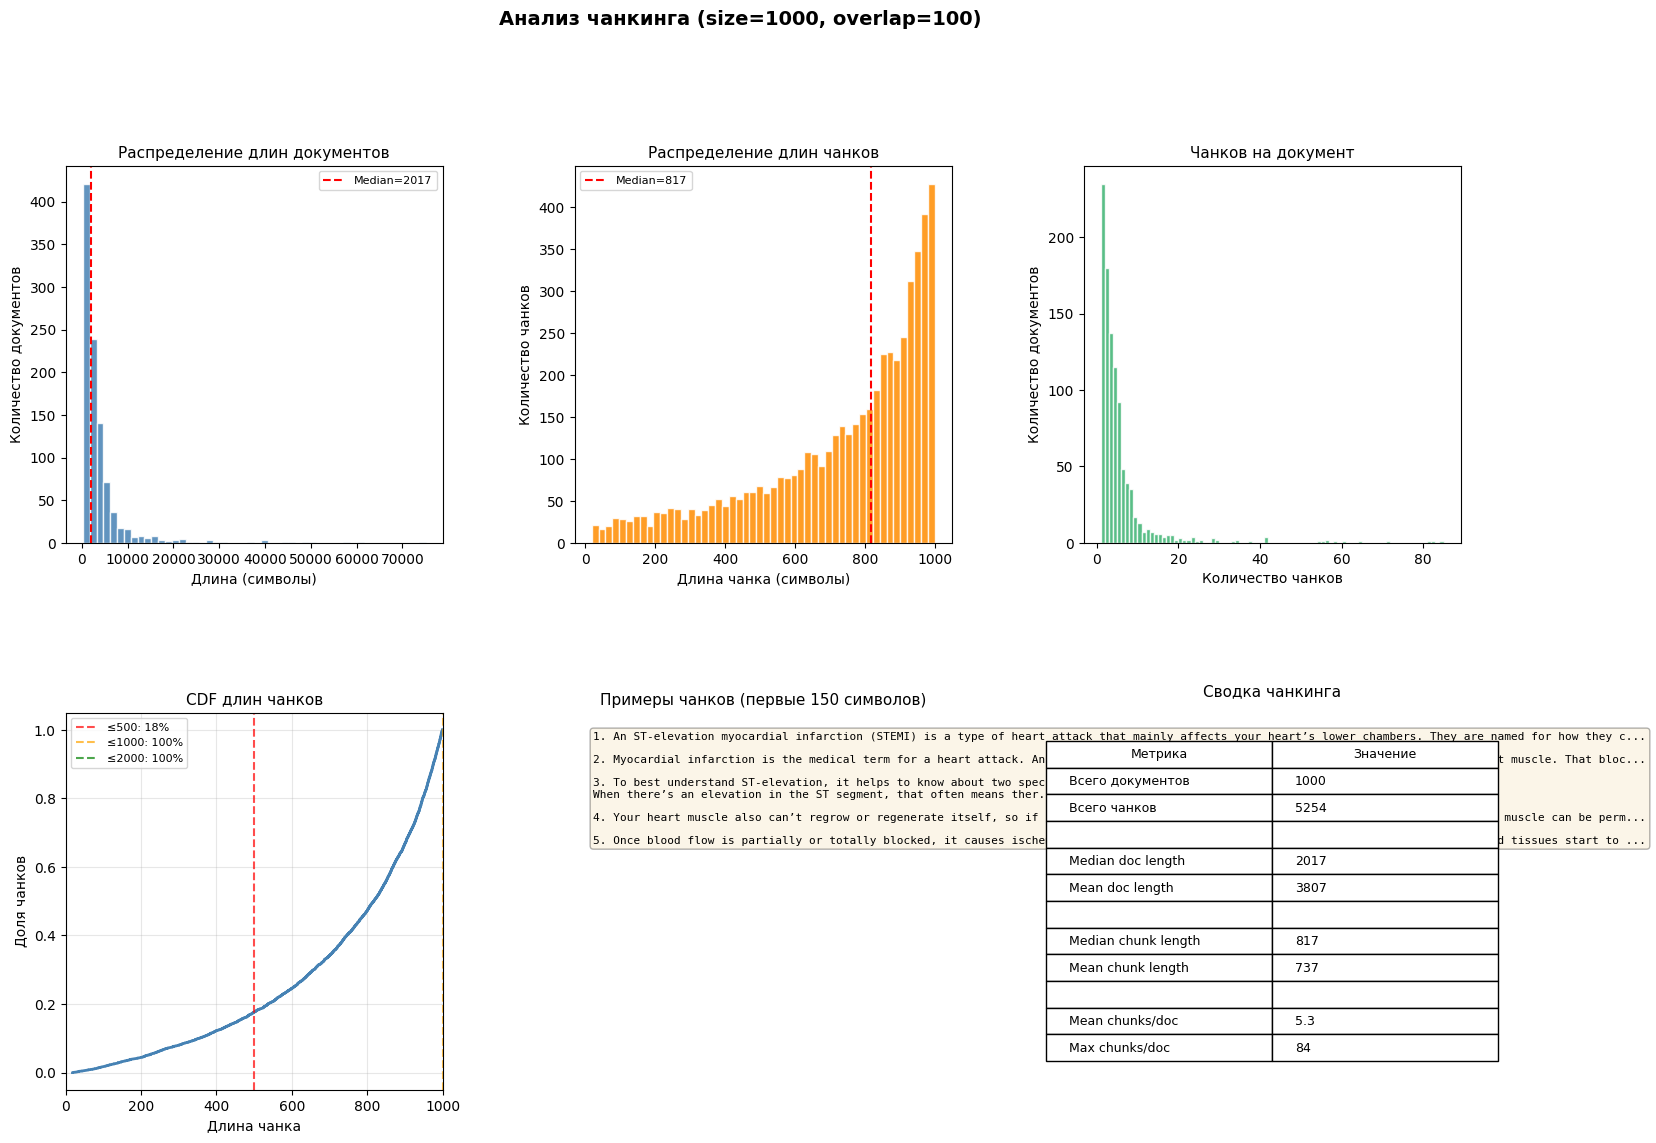

Сохранено: chunking_analysis.png


In [151]:
# Визуализация распределений (в стилистике ноутбука)
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Распределение длин документов
ax1 = fig.add_subplot(gs[0, 0])
doc_len_arr = np.array(doc_lengths)
ax1.hist(doc_len_arr, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax1.axvline(np.median(doc_len_arr), color="red", linestyle="--",
            label=f"Median={np.median(doc_len_arr):.0f}")
ax1.set_title("Распределение длин документов", fontsize=11)
ax1.set_xlabel("Длина (символы)")
ax1.set_ylabel("Количество документов")
ax1.legend(fontsize=8)

# 2. Распределение длин чанков
ax2 = fig.add_subplot(gs[0, 1])
chunk_len_arr = np.array([len(c) for c in chunks])
ax2.hist(chunk_len_arr, bins=50, color="darkorange", edgecolor="white", alpha=0.85)
ax2.axvline(np.median(chunk_len_arr), color="red", linestyle="--",
            label=f"Median={np.median(chunk_len_arr):.0f}")
ax2.set_title("Распределение длин чанков", fontsize=11)
ax2.set_xlabel("Длина чанка (символы)")
ax2.set_ylabel("Количество чанков")
ax2.legend(fontsize=8)

# 3. Чанков на документ
ax3 = fig.add_subplot(gs[0, 2])
chunks_per_doc = []
for text in texts:
    chunks_per_doc.append(len(splitter.split_text(text)))
chunks_per_doc_arr = np.array(chunks_per_doc)
ax3.hist(chunks_per_doc_arr, bins=range(1, max(chunks_per_doc_arr)+2),
         color="mediumseagreen", edgecolor="white", alpha=0.85)
ax3.set_title("Чанков на документ", fontsize=11)
ax3.set_xlabel("Количество чанков")
ax3.set_ylabel("Количество документов")

# 4. CDF длин чанков
ax4 = fig.add_subplot(gs[1, 0])
sorted_chunks = np.sort(chunk_len_arr)
cdf = np.arange(1, len(sorted_chunks) + 1) / len(sorted_chunks)
ax4.plot(sorted_chunks, cdf, color="steelblue", linewidth=2)
for thr, col in [(500, "red"), (1000, "orange"), (2000, "green")]:
    val = np.mean(chunk_len_arr <= thr)
    ax4.axvline(thr, color=col, linestyle="--", alpha=0.7, label=f"≤{thr}: {val*100:.0f}%")
ax4.set_xlim(0, min(5000, sorted_chunks.max()))
ax4.set_title("CDF длин чанков", fontsize=11)
ax4.set_xlabel("Длина чанка")
ax4.set_ylabel("Доля чанков")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. Примеры чанков
ax5 = fig.add_subplot(gs[1, 1])
ax5.axis("off")
sample_chunks = chunks[:5]
sample_text = "\n\n".join([f"{i+1}. {c[:150]}..." for i, c in enumerate(sample_chunks)])
ax5.text(0.05, 0.95, sample_text, transform=ax5.transAxes, fontsize=8,
         verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3))
ax5.set_title("Примеры чанков (первые 150 символов)", fontsize=11)

# 6. Сводная таблица
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
summary = [
    ["Метрика", "Значение"],
    ["Всего документов", f"{len(texts)}"],
    ["Всего чанков", f"{len(chunks)}"],
    ["", ""],
    ["Median doc length", f"{np.median(doc_len_arr):.0f}"],
    ["Mean doc length", f"{np.mean(doc_len_arr):.0f}"],
    ["", ""],
    ["Median chunk length", f"{np.median(chunk_len_arr):.0f}"],
    ["Mean chunk length", f"{np.mean(chunk_len_arr):.0f}"],
    ["", ""],
    ["Mean chunks/doc", f"{np.mean(chunks_per_doc_arr):.1f}"],
    ["Max chunks/doc", f"{np.max(chunks_per_doc_arr):.0f}"],
]
tbl = ax6.table(cellText=summary[1:], colLabels=summary[0],
                loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
ax6.set_title("Сводка чанкинга", fontsize=11, pad=12)

fig.suptitle(f"Анализ чанкинга (size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("chunking_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: chunking_analysis.png")

# 1. Классификация моделькой

In [102]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"  # или "MoritzLaurer/deberta-v3-large-mnli-fever-anli"
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [107]:
candidate_labels = [
    # Естественные науки
    "Physics", "Chemistry", "Biology", "Medicine", "Earth Science",
    # Формальные науки
    "Mathematics", "Computer Science", "Statistics",
    # Инженерия
    "Engineering", "Construction", "Architecture",
    # Гуманитарные
    "History", "Philosophy", "Religion", "Literature", "Art",
    # Социальные
    "Psychology", "Sociology", "Economics", "Law", "Education",
    # Прочее
    "Linguistics", "Web Design", "Business", "Environment"
]

In [109]:
import random

THRESHOLD = 0.3

def classify_with_confidence(text, threshold=THRESHOLD):
    result = classifier(text, candidate_labels, multi_label=True)
    top_label = result["labels"][0]
    top_score = result["scores"][0]

    if top_score < threshold:
        return "Unclassified", top_score
    return top_label, top_score

# Тест на случайной выборке
sample = random.sample(chunks, 10)
results = [classify_with_confidence(t) for t in sample]

for text, (label, score) in zip(sample, results):
    print(f"[{score:.3f}] {label:<20} | {text[:60]}...")

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[0.559] Education            | - Multisensory lessons include auditory, visual, and kinesth...
[0.259] Unclassified         | Using photocatalysis for energy applications depends, more t...
[0.727] Education            | Request for third party comments:
The School of Education at...
[0.761] Education            | Edmentum is proud to provide a variety of online solutions t...
[0.920] Mathematics          | Paraconsistency can also offer new insight into certain big-...
[0.232] Unclassified         | . Research findings in this area may ultimately contribute t...
[0.629] Medicine             | Achievements in Public Health, 1900-1999 Impact of Vaccines ...
[0.077] Unclassified         | |Wikimedia Waterworld Interplanetary Bong Fillers Associatio...
[0.786] Environment          | No one type of exercise is suitable for everyone. The goal s...
[0.818] Environment          | Fioricet May Make You Dependence
Taking high doses of Fioric...


In [ ]:
# Ваши классы (например, области знаний)
candidate_labels = [
    "Computer Science", "Physics", "Mathematics",
    "Biology", "Medicine", "Chemistry",
    "Engineering", "Economics", "Psychology"
]

result = classifier(chunks, candidate_labels, multi_label=True)
# Берем топ-3
top_3_labels = result["labels"][:3]
top_3_scores = result["scores"][:3]

# 2. KMEans

In [7]:
%pip install -q sentence-transformers

### локально

In [ ]:
from sentence_transformers import SentenceTransformer

# EMBEDDER_NAME = "BAAI/bge-m3"
EMBEDDER_NAME = "BAAI/bge-large-en-v1.5"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Загрузка эмбеддера {EMBEDDER_NAME} на {DEVICE}...")
embedder = SentenceTransformer(EMBEDDER_NAME, device=DEVICE)
print(f"Эмбеддер загружен. Размерность: {embedder.get_embedding_dimension()}")

In [57]:
# Векторизация батчами (bge-m3 нормально работает с длинными текстами)
BATCH_SIZE = 32
MAX_LENGTH = 8192  # максимальная длина для bge-m3

print(f"Векторизация {len(chunks)} чанков (batch_size={BATCH_SIZE})...")

# bge-m3 рекомендует нормализовать эмбеддинги для cosine similarity
embeddings = embedder.encode(
    chunks,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,  # важно для cosine similarity в KMeans
    convert_to_numpy=True
)

print(f"Форма тензора эмбеддингов: {embeddings.shape}")
print(f"Пример нормы первого эмбеддинга: {np.linalg.norm(embeddings[0]):.4f}")

Векторизация 5254 чанков (batch_size=32)...


Batches:   0%|          | 0/165 [00:00<?, ?it/s]

Форма тензора эмбеддингов: (5254, 1024)
Пример нормы первого эмбеддинга: 1.0000


### polza.ai

In [158]:
import openai
import numpy as np
from tqdm.auto import tqdm
from sklearn.preprocessing import normalize
from google.colab import userdata

# ── Настройка клиента Polza.ai ──────────────────────────────────────────────
POLZA_API_KEY = userdata.get('POLZA_API_KEY')  # ← вставь свой ключ
POLZA_BASE_URL = "https://api.polza.ai/v1"
EMBEDDER_NAME = "qwen/qwen3-embedding-8b"  # или "text-embedding-3-small"

client = openai.OpenAI(
    base_url=POLZA_BASE_URL,
    api_key=POLZA_API_KEY
)

print(f"Эмбеддер: {EMBEDDER_NAME}")
print(f"Эндпоинт: {POLZA_BASE_URL}")

Эмбеддер: qwen/qwen3-embedding-8b
Эндпоинт: https://api.polza.ai/v1


In [159]:
# ── Функция векторизации батчами ────────────────────────────────────────────
BATCH_SIZE = 500  # OpenAI принимает до 2048, но 100 безопаснее для rate limit

def get_embeddings_api(chunks, model=EMBEDDER_NAME, batch_size=BATCH_SIZE, max_retries=3):
    """
    Получает эмбеддинги через Polza.ai API батчами.
    С retry-логикой на случай rate limit / временных ошибок.
    """
    all_embeddings = []
    failed_batches = []

    for i in tqdm(range(0, len(chunks), batch_size), desc="Embedding via API"):
        batch = chunks[i:i + batch_size]

        # Retry-логика
        for attempt in range(max_retries):
            try:
                response = client.embeddings.create(
                    model=model,
                    input=batch
                )
                # Извлекаем эмбеддинги (сохраняем порядок через sort по index)
                batch_embeddings = [item.embedding for item in sorted(response.data, key=lambda x: x.index)]
                all_embeddings.extend(batch_embeddings)
                break
            except Exception as e:
                if attempt < max_retries - 1:
                    import time
                    time.sleep(2 ** attempt)  # экспоненциальная задержка
                else:
                    print(f"  ⚠ Batch {i//batch_size} failed after {max_retries} attempts: {e}")
                    failed_batches.append(i // batch_size)
                    # Fallback: нулевой вектор нужной размерности
                    all_embeddings.extend([[0.0] * 3072] * len(batch))

    if failed_batches:
        print(f"  ⚠ Проваленных батчей: {len(failed_batches)} — {failed_batches}")

    return np.array(all_embeddings)

In [160]:
len(chunks)

5254

In [161]:
# ── Векторизация ────────────────────────────────────────────────────────────
print(f"Векторизация {len(chunks)} чанков (batch_size={BATCH_SIZE})...")

embeddings = get_embeddings_api(chunks)

# Нормализация (важно для cosine similarity в KMeans!)
# text-embedding-3-* уже возвращает нормализованные векторы, но перестрахуемся
embeddings = normalize(embeddings, norm='l2')

print(f"\nФорма тензора эмбеддингов: {embeddings.shape}")
print(f"Пример нормы первого эмбеддинга: {np.linalg.norm(embeddings[0]):.4f}")
print(f"Размерность: {embeddings.shape[1]}")

Векторизация 5254 чанков (batch_size=500)...


Embedding via API:   0%|          | 0/11 [00:00<?, ?it/s]


Форма тензора эмбеддингов: (5254, 4096)
Пример нормы первого эмбеддинга: 1.0000
Размерность: 4096


In [162]:
np.save("embeddings_polza.npy", embeddings)
# Загрузка:
# embeddings = np.load("embeddings_polza.npy")

Статистика попарного cosine similarity (выборка 1000):
  Mean:   0.1684
  Median: 0.1612
  P10:    0.0869
  P90:    0.2579
  Min:    -0.0771
  Max:    0.9160


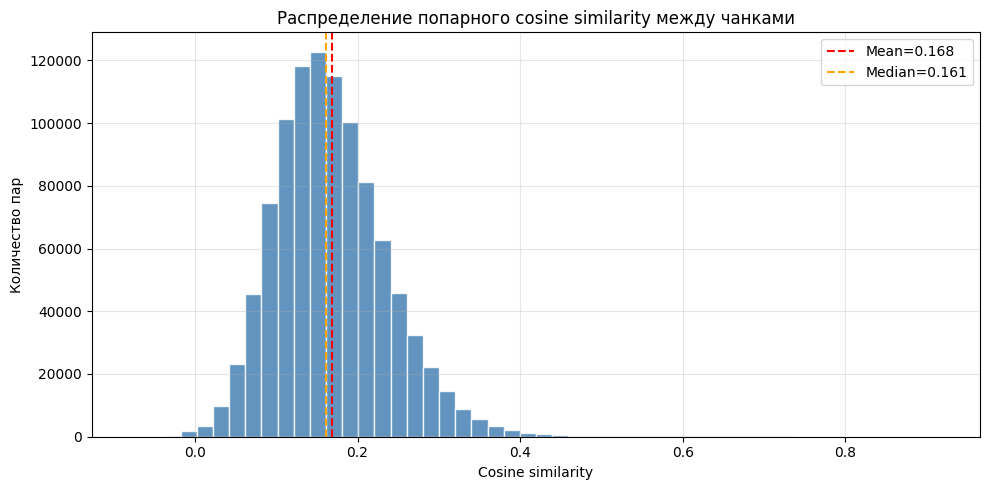

In [163]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Берем случайную выборку 1000 чанков (иначе слишком долго)
sample_size = min(1000, len(embeddings))
sample_idx = np.random.choice(len(embeddings), sample_size, replace=False)
sample_embs = embeddings[sample_idx]

# Считаем попарное сходство
sim_matrix = cosine_similarity(sample_embs)

# Убираем диагональ (само-сходство = 1)
np.fill_diagonal(sim_matrix, 0)

# Статистика
print(f"Статистика попарного cosine similarity (выборка {sample_size}):")
print(f"  Mean:   {sim_matrix.mean():.4f}")
print(f"  Median: {np.median(sim_matrix):.4f}")
print(f"  P10:    {np.percentile(sim_matrix, 10):.4f}")
print(f"  P90:    {np.percentile(sim_matrix, 90):.4f}")
print(f"  Min:    {sim_matrix.min():.4f}")
print(f"  Max:    {sim_matrix.max():.4f}")

# Гистограмма
plt.figure(figsize=(10, 5))
plt.hist(sim_matrix.flatten(), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(sim_matrix.mean(), color="red", linestyle="--", label=f"Mean={sim_matrix.mean():.3f}")
plt.axvline(np.median(sim_matrix), color="orange", linestyle="--", label=f"Median={np.median(sim_matrix):.3f}")
plt.title("Распределение попарного cosine similarity между чанками")
plt.xlabel("Cosine similarity")
plt.ylabel("Количество пар")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("similarity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [164]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Пробуем разные K
print("KMeans с разными K:")
results = []
sil_scores = []
inertias = []
km_models = {}

K_VALUES = [5, 8, 10, 12, 15, 20]

for k in K_VALUES:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    cluster_labels = km.fit_predict(embeddings)

    # Silhouette score на выборке для скорости
    sample_idx = np.random.choice(len(embeddings), min(5000, len(embeddings)), replace=False)
    score = silhouette_score(embeddings[sample_idx], cluster_labels[sample_idx])

    cluster_sizes = [list(cluster_labels).count(i) for i in range(k)]
    results.append({
        'k': k,
        'score': score,
        'min_size': min(cluster_sizes),
        'max_size': max(cluster_sizes),
        'imbalance': max(cluster_sizes) / max(min(cluster_sizes), 1)
    })

    sil_scores.append(score)
    inertias.append(km.inertia_)
    km_models[k] = km

    print(f"  K={k:2d}: silhouette={score:.4f}, sizes=[{min(cluster_sizes)}, {max(cluster_sizes)}], imbalance={max(cluster_sizes)/max(min(cluster_sizes), 1):.1f}x")

# Выбираем лучший K
best_result = max(results, key=lambda x: x['score'])
BEST_K = best_result['k']
BEST_SCORE = sil_scores[int(np.argmax(sil_scores))]
print(f"\n✓ Лучший K={BEST_K} (silhouette={best_result['score']:.4f})")

KMeans с разными K:
  K= 5: silhouette=0.0175, sizes=[938, 1244], imbalance=1.3x
  K= 8: silhouette=0.0152, sizes=[157, 886], imbalance=5.6x
  K=10: silhouette=0.0193, sizes=[228, 759], imbalance=3.3x
  K=12: silhouette=0.0206, sizes=[191, 743], imbalance=3.9x
  K=15: silhouette=0.0202, sizes=[86, 644], imbalance=7.5x
  K=20: silhouette=0.0221, sizes=[53, 429], imbalance=8.1x

✓ Лучший K=20 (silhouette=0.0221)


In [165]:
BEST_K = 12

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10, max_iter=300)
cluster_labels = km_final.fit_predict(embeddings)
cluster_centers = km_final.cluster_centers_
counts = np.bincount(cluster_labels)

print(f"Кластеров: {len(set(cluster_labels))}")
print(f"Размеры: {counts}")

Кластеров: 12
Размеры: [638 216 376 412 743 361 451 191 563 304 445 554]


In [166]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA визуализация
print("Применение PCA для визуализации...")
pca = PCA(n_components=2, random_state=42)
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)
embeddings_2d = pca.fit_transform(embeddings_scaled)

explained_var = pca.explained_variance_ratio_
print(f"Объясненная дисперсия: PC1={explained_var[0]*100:.1f}%, PC2={explained_var[1]*100:.1f}%")

# Центроиды в PCA пространстве
centroids_2d = pca.transform(scaler.transform(cluster_centers))

Применение PCA для визуализации...
Объясненная дисперсия: PC1=2.1%, PC2=1.7%


## Визуализация


Применение PCA для визуализации...
Объяснённая дисперсия: PC1=2.1%, PC2=1.7%, сумма=3.8%


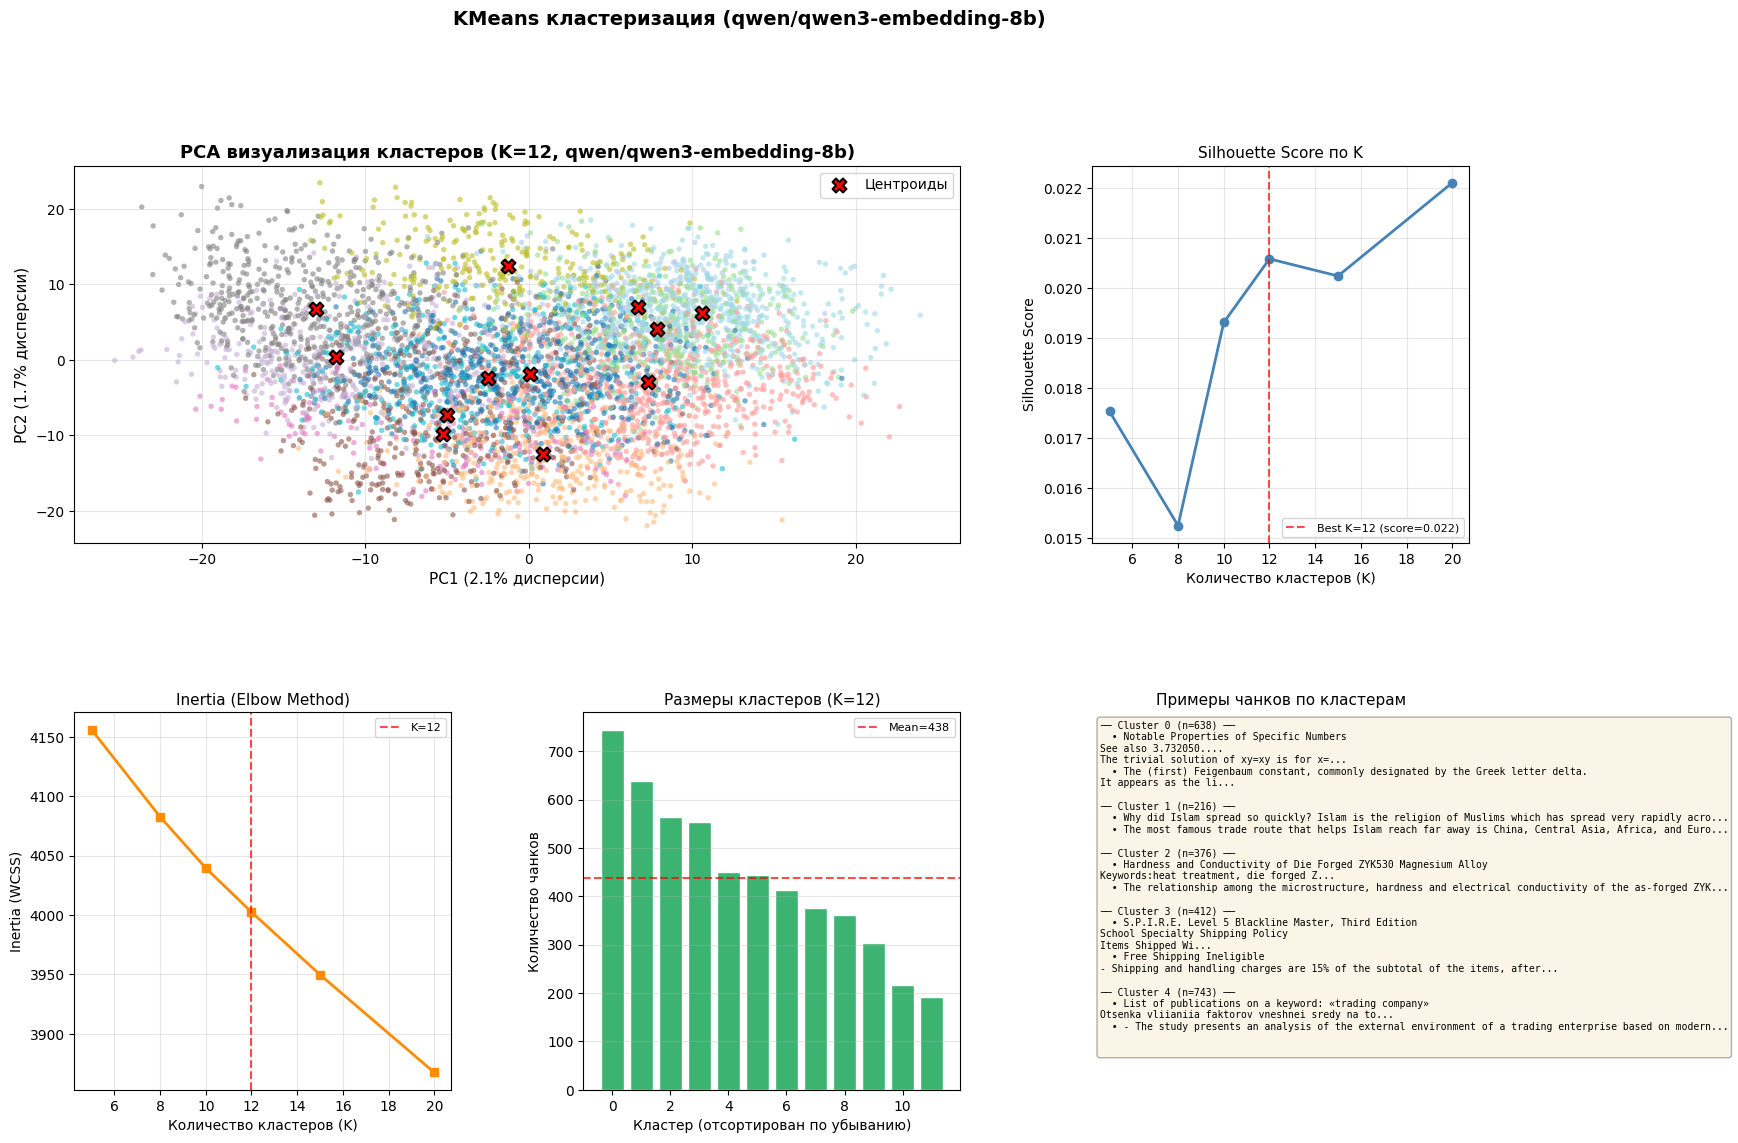


Сохранено: kmeans_pca_analysis.png


In [168]:
print("\nПрименение PCA для визуализации...")
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings_scaled)
explained_var = pca.explained_variance_ratio_

# Центроиды в PCA-пространстве
centroids_2d = pca.transform(scaler.transform(cluster_centers))

print(f"Объяснённая дисперсия: PC1={explained_var[0]*100:.1f}%, "
      f"PC2={explained_var[1]*100:.1f}%, сумма={sum(explained_var)*100:.1f}%")

# ═══════════════════════════════════════════════════════════════════════════════
# 4. Визуализация (6 панелей в стилистике ноутбука)
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. PCA scatter с кластерами ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
scatter = ax1.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=cluster_labels,
    cmap='tab20',
    alpha=0.6,
    s=15,
    edgecolors='none'
)

# Центроиды (красные кресты)
ax1.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    c='red',
    marker='X',
    s=100,
    edgecolors='black',
    linewidths=1.5,
    label='Центроиды',
    zorder=5
)

ax1.set_title(f"PCA визуализация кластеров (K={BEST_K}, {EMBEDDER_NAME})",
              fontsize=13, fontweight="bold")
ax1.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% дисперсии)", fontsize=11)
ax1.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% дисперсии)", fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# ── 2. Silhouette Score по K ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(K_VALUES, sil_scores, color="steelblue", linewidth=2, marker="o")
ax2.axvline(BEST_K, color="red", linestyle="--", alpha=0.7,
            label=f"Best K={BEST_K} (score={BEST_SCORE:.3f})")
ax2.set_title("Silhouette Score по K", fontsize=11)
ax2.set_xlabel("Количество кластеров (K)")
ax2.set_ylabel("Silhouette Score")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── 3. Elbow method (inertia) ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(K_VALUES, inertias, color="darkorange", linewidth=2, marker="s")
ax3.axvline(BEST_K, color="red", linestyle="--", alpha=0.7, label=f"K={BEST_K}")
ax3.set_title("Inertia (Elbow Method)", fontsize=11)
ax3.set_xlabel("Количество кластеров (K)")
ax3.set_ylabel("Inertia (WCSS)")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# ── 4. Распределение размеров кластеров ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
sorted_counts = np.sort(counts)[::-1]
ax4.bar(range(len(sorted_counts)), sorted_counts,
        color="mediumseagreen", edgecolor="white")
ax4.axhline(counts.mean(), color="red", linestyle="--", alpha=0.7,
            label=f"Mean={counts.mean():.0f}")
ax4.set_title(f"Размеры кластеров (K={BEST_K})", fontsize=11)
ax4.set_xlabel("Кластер (отсортирован по убыванию)")
ax4.set_ylabel("Количество чанков")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis="y")

# ── 5. Примеры чанков из кластеров ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")
sample_text = ""
for i in range(min(5, BEST_K)):
    cluster_chunks = [chunks[j] for j in np.where(cluster_labels == i)[0]][:2]
    sample_text += f"── Cluster {i} (n={counts[i]}) ──\n"
    for c in cluster_chunks:
        sample_text += f"  • {c[:100]}...\n"
    sample_text += "\n"

ax5.text(0.02, 0.98, sample_text, transform=ax5.transAxes, fontsize=7,
         verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3))
ax5.set_title("Примеры чанков по кластерам", fontsize=11)

fig.suptitle(f"KMeans кластеризация ({EMBEDDER_NAME})",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("kmeans_pca_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nСохранено: kmeans_pca_analysis.png")

## Определение доменов

In [63]:
%pip install -q openai

from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import time

In [170]:
# Получаем репрезентативные чанки для каждого кластера
N_REPRESENTATIVE = 5

print(f"Подготовка репрезентативных чанков для {BEST_K} кластеров...")

cluster_representatives = {}
for cluster_id in range(BEST_K):
    center = cluster_centers[cluster_id].reshape(1, -1)
    similarities = cosine_similarity(embeddings, center).flatten()
    top_indices = np.argsort(similarities)[::-1][:N_REPRESENTATIVE]

    cluster_representatives[cluster_id] = {
        'chunks': [chunks[i] for i in top_indices],
        'indices': top_indices
    }

print(f"Готово! Подготовлено текстов: {BEST_K * N_REPRESENTATIVE}")

Подготовка репрезентативных чанков для 12 кластеров...
Готово! Подготовлено текстов: 60


In [173]:
import openai
from google.colab import userdata

POLZA_API_KEY = userdata.get('POLZA_API_KEY')
POLZA_BASE_URL = "https://api.polza.ai/v1"

# Рекомендация: GPT-4.1-mini — дёшево и качественно
LLM_MODEL = "openai/gpt-oss-120b"

client = openai.OpenAI(
    base_url=POLZA_BASE_URL,
    api_key=POLZA_API_KEY
)

print(f"LLM-судья настроен: {LLM_MODEL}")
print(f"Эндпоинт: {POLZA_BASE_URL}")

LLM-судья настроен: openai/gpt-oss-120b
Эндпоинт: https://api.polza.ai/v1


In [174]:
# Промпт для LLM-судьи
LLM_PROMPT_TEMPLATE = """Ты эксперт по классификации текстов.
Проанализируй следующие {n} текстов из одного кластера и определи их общий домен/тему.

Верни ТОЛЬКО название домена в формате JSON: {{"domain": "Название"}}

Варианты доменов (выбери наиболее подходящий или предложи свой):
- Mathematics
- Physics
- Chemistry
- Biology
- Medicine
- Computer Science
- Engineering
- Economics
- History
- Literature
- Law
- Philosophy
- Psychology
- Education
- General Knowledge

Тексты:
{texts}

Ответ:"""

MAX_CHARS = 2000

def ask_llm_judge(chunks, max_chars=MAX_CHARS):
    """
    Отправляет репрезентативные чанки в LLM и возвращает домен.
    """
    # Обрезаем тексты и формируем список
    texts_block = ""
    for i, c in enumerate(chunks):
        truncated = c[:max_chars]
        texts_block += f"{i+1}. {truncated}\n\n"

    prompt = LLM_PROMPT_TEMPLATE.format(n=len(chunks), texts=texts_block)

    try:
        response = client.chat.completions.create(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,  # низкая для стабильности
            max_tokens=100,
            timeout=30
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"ERROR: {str(e)}"

# Тест на первом кластере
print("Тестовый запрос к LLM...")
test_response = ask_llm_judge(cluster_representatives[0]['chunks'])
print(f"Ответ LLM: {test_response}")

Тестовый запрос к LLM...
Ответ LLM: 


In [175]:
# Проходим по всем кластерам
print(f"\nОпрос LLM-судьи для {BEST_K} кластеров...")

cluster_domains = {}
errors = []

for cluster_id in tqdm(range(BEST_K), desc="LLM judge"):
    rep_chunks = cluster_representatives[cluster_id]['chunks']
    raw_response = ask_llm_judge(rep_chunks)

    # Пытаемся распарсить JSON из ответа
    try:
        json_match = re.search(r'\{[^}]*"domain"[^}]*\}', raw_response, re.IGNORECASE)
        if json_match:
            parsed = json.loads(json_match.group())
            domain = parsed['domain'].strip()
        else:
            domain = raw_response.strip(' "\'')
    except (json.JSONDecodeError, AttributeError):
        domain = raw_response.strip(' "\'')
        errors.append((cluster_id, raw_response))

    cluster_domains[cluster_id] = domain
    time.sleep(0.5)

print(f"\nГотово! Получено доменов: {len(cluster_domains)}")
print(f"Ошибок: {len(errors)}")
if errors:
    print(f"Примеры ошибок: {errors[:3]}")


Опрос LLM-судьи для 12 кластеров...


LLM judge:   0%|          | 0/12 [00:00<?, ?it/s]


Готово! Получено доменов: 12
Ошибок: 0


In [176]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import Counter

# ── PCA для 2D ─────────────────────────────────────────────────────────────
print("Применение PCA для визуализации доменов...")
pca = PCA(n_components=2, random_state=42)
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)
embeddings_2d = pca.fit_transform(embeddings_scaled)

explained_var = pca.explained_variance_ratio_
print(f"Объяснённая дисперсия: PC1={explained_var[0]*100:.1f}%, PC2={explained_var[1]*100:.1f}%")

# ── Маппинг кластер → домен ────────────────────────────────────────────────
cluster_to_domain = {i: cluster_domains[i] for i in range(BEST_K)}
chunk_domains = [cluster_to_domain[int(label)] for label in cluster_labels]

unique_domains = sorted(set(chunk_domains))
domain_counter = Counter(chunk_domains)

# Цветовая палитра (как в стилистике ноутбука)
palette = plt.cm.tab10(np.linspace(0, 1, len(unique_domains)))
domain_colors = {d: palette[i] for i, d in enumerate(unique_domains)}

print(f"\nУникальных доменов: {len(unique_domains)}")
for d, c in domain_counter.most_common():
    print(f"  {d:<20} {c:>5} чанков ({c/len(chunks)*100:.1f}%)")

Применение PCA для визуализации доменов...
Объяснённая дисперсия: PC1=2.1%, PC2=1.7%

Уникальных доменов: 6
                        2380 чанков (45.3%)
  Medicine               867 чанков (16.5%)
  Engineering            827 чанков (15.7%)
  Biology                552 чанков (10.5%)
  Education              412 чанков (7.8%)
  History                216 чанков (4.1%)


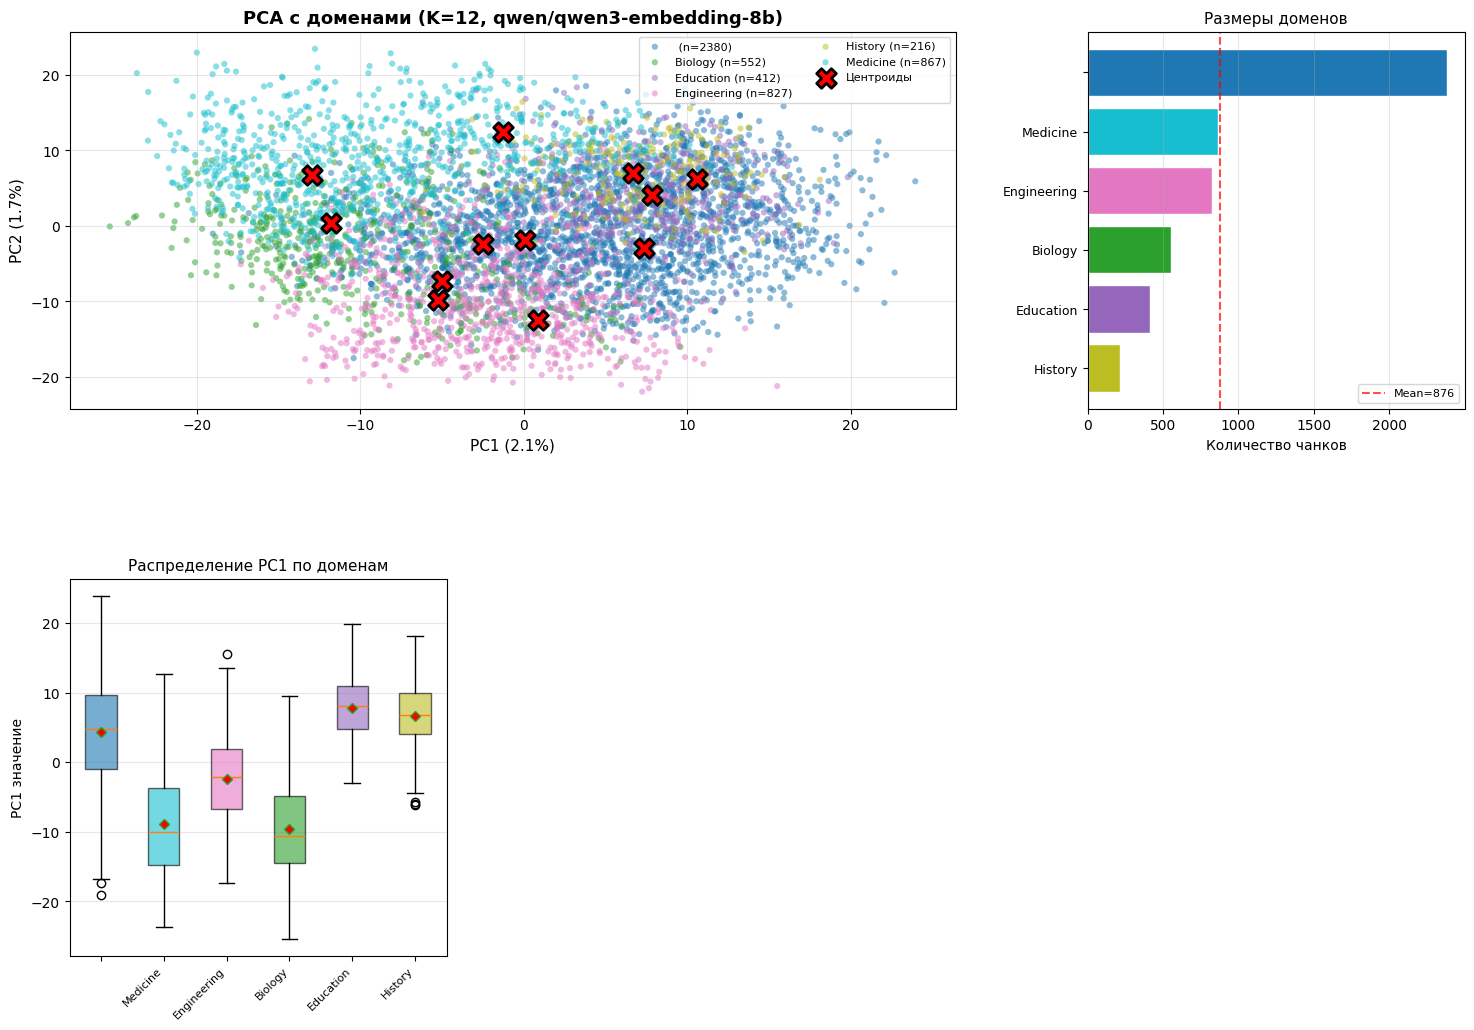

Сохранено: domains_final.png


In [177]:
# ── Визуализация в стилистике ноутбука (gridspec 2x3) ──────────────────────
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. PCA scatter с доменами ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])

for domain in unique_domains:
    mask = np.array([d == domain for d in chunk_domains])
    ax1.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[domain_colors[domain]],
        alpha=0.5,
        s=20,
        label=f"{domain} (n={mask.sum()})",
        edgecolors='none'
    )

# Центроиды
centroids_2d = pca.transform(scaler.transform(cluster_centers))
ax1.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='red', marker='X', s=200, edgecolors='black',
    linewidths=2, label='Центроиды', zorder=5
)

ax1.set_title(f"PCA с доменами (K={BEST_K}, {EMBEDDER_NAME})",
              fontsize=13, fontweight="bold")
ax1.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)", fontsize=11)
ax1.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)", fontsize=11)
ax1.legend(fontsize=8, loc='best', ncol=2)
ax1.grid(True, alpha=0.3)

# ── 2. Распределение размеров доменов (bar plot) ────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
domains_sorted = [d for d, _ in domain_counter.most_common()]
counts_sorted = [c for _, c in domain_counter.most_common()]
colors_sorted = [domain_colors[d] for d in domains_sorted]

bars = ax2.barh(range(len(domains_sorted)), counts_sorted,
                color=colors_sorted, edgecolor="white")
ax2.set_yticks(range(len(domains_sorted)))
ax2.set_yticklabels(domains_sorted, fontsize=9)
ax2.axvline(np.mean(counts_sorted), color="red", linestyle="--", alpha=0.7,
            label=f"Mean={np.mean(counts_sorted):.0f}")
ax2.set_title("Размеры доменов", fontsize=11)
ax2.set_xlabel("Количество чанков")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis="x")
ax2.invert_yaxis()

# ── 3. Распределение PC1 по доменам (box-like) ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
positions = []
data_by_domain = []
for i, domain in enumerate(domains_sorted):
    mask = np.array([d == domain for d in chunk_domains])
    data_by_domain.append(embeddings_2d[mask, 0])
    positions.append(i)

bp = ax3.boxplot(data_by_domain, positions=positions, vert=True,
                 patch_artist=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=5))

for patch, color in zip(bp['boxes'], colors_sorted):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax3.set_xticks(positions)
ax3.set_xticklabels(domains_sorted, rotation=45, ha="right", fontsize=8)
ax3.set_title("Распределение PC1 по доменам", fontsize=11)
ax3.set_ylabel("PC1 значение")
ax3.grid(True, alpha=0.3, axis="y")

plt.savefig("domains_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: domains_final.png")

In [178]:
samples = []
for domain in domains_sorted[:5]:
    mask = np.array([d == domain for d in chunk_domains])
    domain_chunks = [chunks[i] for i in np.where(mask)[0]][:1]
    for c in domain_chunks:
        samples.append(f"── {domain} (n={mask.sum()}) ──\n{c[:300]}...")

print(*samples, sep='\n\n')

──  (n=2380) ──
The copyrights for articles in this journal are retained by the author(s), with first publication rights granted to the journal. By virtue of their appearance in this open-access journal, articles are free to use with proper attribution in educational and other non-commercial settings....

── Medicine (n=867) ──
An ST-elevation myocardial infarction (STEMI) is a type of heart attack that mainly affects your heart’s lower chambers. They are named for how they change the appearance of your heart’s electrical activity on a certain type of diagnostic test. STEMIs tend to be more severe and dangerous compared to...

── Engineering (n=827) ──
Hardness and Conductivity of Die Forged ZYK530 Magnesium Alloy
Keywords:heat treatment, die forged ZYK530 Mg alloy, hardness, conductivity...

── Biology (n=552) ──
How scary might it look if you thought you had already turned off the electric stove, but it continuously made noise?
Of course, there is a reasonable cause why your electric